# 04 · Modelo SARIMA
**Proyecto ML — Bizkaibus 2026**

SARIMA(p,d,q)(P,D,Q)[12] para series mensuales con estacionalidad anual.

**Configuración de partida** (basada en ACF/PACF del notebook 02):
- `(1,1,1)(1,1,1)[12]` — ajuste automático por línea si AIC lo mejora


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error
import warnings, time
warnings.filterwarnings('ignore')

plt.rcParams.update({'figure.dpi': 110, 'font.size': 11})

train = pd.read_csv('../data/train.csv', parse_dates=['fecha'])
test  = pd.read_csv('../data/test.csv',  parse_dates=['fecha'])
df_all = pd.read_csv('../data/train_merged.csv', parse_dates=['fecha'])

lineas = sorted(df_all['linea'].unique())
print(f"Líneas: {len(lineas)}")


Líneas: 104


In [5]:
def entrenar_sarima(linea, train_df, test_df, order=(1,1,1), seasonal_order=(1,1,1,12)):
    """Entrena SARIMAX para una línea y evalúa en test."""
    tr = train_df[train_df['linea'] == linea].sort_values('fecha')
    te = test_df[test_df['linea'] == linea].sort_values('fecha')
    
    if len(tr) < 24:
        return None
    
    serie = tr.set_index('fecha')['viajeros_total']
    # Inferir frecuencia automáticamente
    if serie.index.freq is None:
        serie = serie.asfreq('MS')
    
    try:
        model = SARIMAX(serie, order=order, seasonal_order=seasonal_order,
                        enforce_stationarity=False, enforce_invertibility=False)
        fit = model.fit(disp=False)
        
        # Predecir en test (12 pasos adelante)
        forecast = fit.forecast(steps=len(te))
        y_true = te['viajeros_total'].values
        y_pred = np.clip(forecast.values, 0, None)
        
        mae  = mean_absolute_error(y_true, y_pred)
        rmse = np.sqrt(mean_squared_error(y_true, y_pred))
        mape = np.mean(np.abs((y_true - y_pred) / (y_true + 1e-9))) * 100
        
        return {
            'linea': linea, 'mae': mae, 'rmse': rmse, 'mape': mape,
            'aic': fit.aic, 'fit': fit, 'serie': serie,
            'y_true': y_true, 'y_pred': y_pred,
            'fechas_test': te['fecha'].values,
        }
    except Exception as e:
        return None

print("Función SARIMA definida.")


Función SARIMA definida.


In [6]:
# Entrenamiento en todas las líneas
resultados_sarima = {}
metricas_sarima = []
start = time.time()

for i, linea in enumerate(lineas):
    res = entrenar_sarima(linea, train, test)
    if res:
        resultados_sarima[linea] = res
        metricas_sarima.append({
            'linea': linea, 'mae': res['mae'], 
            'rmse': res['rmse'], 'mape': res['mape'], 'aic': res['aic']
        })
    if (i+1) % 20 == 0:
        print(f"  {i+1}/{len(lineas)} líneas... ({time.time()-start:.0f}s)")

metricas_sarima_df = pd.DataFrame(metricas_sarima)
metricas_sarima_df.to_csv('../data/metricas_sarima.csv', index=False)
print(f"\n✓ SARIMA entrenado para {len(metricas_sarima_df)} líneas en {time.time()-start:.0f}s")
print()
print("=== Métricas globales SARIMA ===")
print(metricas_sarima_df[['mae','rmse','mape']].describe().round(2))


  20/104 líneas... (7s)
  40/104 líneas... (13s)
  60/104 líneas... (19s)
  80/104 líneas... (24s)
  100/104 líneas... (29s)

✓ SARIMA entrenado para 91 líneas en 30s

=== Métricas globales SARIMA ===
                mae          rmse          mape
count  9.100000e+01  9.100000e+01  9.100000e+01
mean   1.867813e+13  2.337399e+13  3.965570e+13
std    1.548460e+14  1.912015e+14  3.200750e+14
min    0.000000e+00  0.000000e+00  0.000000e+00
25%    1.173940e+03  1.566070e+03  1.146000e+01
50%    3.359680e+03  5.612900e+03  2.036000e+01
75%    9.267640e+03  1.484896e+04  1.000000e+02
max    1.467202e+15  1.810653e+15  3.031243e+15


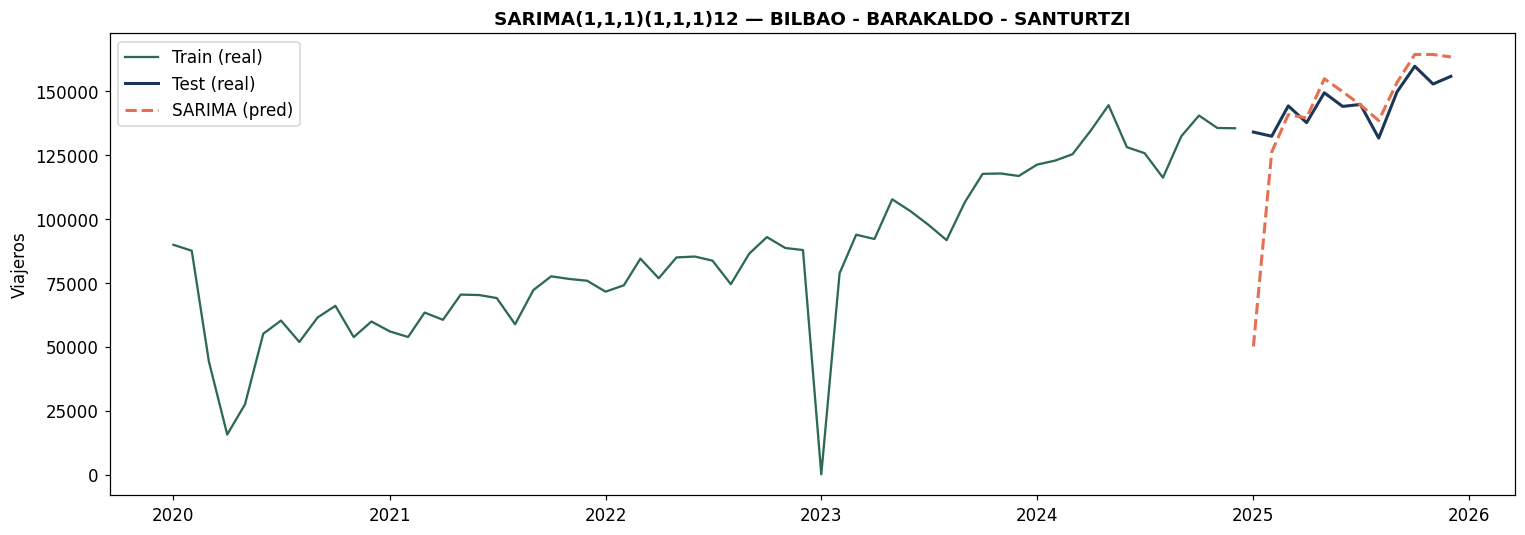

MAPE: 8.5%  |  AIC: 831


In [7]:
# Visualización ejemplo
linea_ref = train.groupby('linea')['viajeros_total'].sum().idxmax()
if linea_ref in resultados_sarima:
    res = resultados_sarima[linea_ref]
    fechas = pd.DatetimeIndex(res['fechas_test'])
    
    fig, ax = plt.subplots(figsize=(14, 5))
    ax.plot(res['serie'].index, res['serie'].values, color='#2d6a4f', label='Train (real)', linewidth=1.5)
    ax.plot(fechas, res['y_true'], color='#1d3557', label='Test (real)', linewidth=2)
    ax.plot(fechas, res['y_pred'], color='#e76f51', label='SARIMA (pred)', linewidth=2, linestyle='--')
    ax.set_title(f'SARIMA(1,1,1)(1,1,1)12 — {linea_ref[:50]}', fontsize=12, fontweight='bold')
    ax.set_ylabel('Viajeros')
    ax.legend()
    plt.tight_layout()
    plt.show()
    print(f"MAPE: {res['mape']:.1f}%  |  AIC: {res['aic']:.0f}")


In [8]:
# Predicciones 2026 con SARIMA
predicciones_sarima_2026 = []

for linea, res in resultados_sarima.items():
    try:
        forecast_2026 = res['fit'].forecast(steps=12 + 12)  # avanzar 12 meses (2025) + 12 (2026)
        # Solo queremos los últimos 12 (2026) — pero el modelo ya tiene train hasta dic 2024
        # Reentrenar incluyendo 2025
        tr_full = df_all[df_all['linea'] == linea].sort_values('fecha')
        serie_full = tr_full.set_index('fecha')['viajeros_total']
        if serie_full.index.freq is None:
            serie_full = serie_full.asfreq('MS')
        
        model_full = SARIMAX(serie_full, order=(1,1,1), seasonal_order=(1,1,1,12),
                             enforce_stationarity=False, enforce_invertibility=False)
        fit_full = model_full.fit(disp=False)
        fc = fit_full.forecast(steps=12)
        fc_clipped = np.clip(fc.values, 0, None)
        
        fechas_2026 = pd.date_range('2026-01-01', periods=12, freq='MS')
        for fecha, pred in zip(fechas_2026, fc_clipped):
            predicciones_sarima_2026.append({
                'linea': linea, 'fecha': fecha, 'año': 2026,
                'mes': fecha.month, 'viajeros_pred_sarima': pred,
            })
    except:
        pass

pred_sarima_2026_df = pd.DataFrame(predicciones_sarima_2026)
pred_sarima_2026_df.to_csv('../data/predicciones_2026_sarima.csv', index=False)
print(f"✓ Predicciones SARIMA 2026: {pred_sarima_2026_df.shape}")


✓ Predicciones SARIMA 2026: (1092, 5)
